# Лабораторная работа

**Задача:** предсказание прогрессирования диабета через год после базового обследования.

**Датасет:** Diabetes — 442 пациента, 10 признаков (возраст, пол, ИМТ, давление, 6 показателей крови).

**Модели:**
1. `StackingRegressor` (RandomForest + GradientBoosting + ExtraTrees → Ridge)
2. `MLPRegressor` (многослойный персептрон, sklearn)
3. `gmdh.Combi` — линейный метод МГУА (COMBI)
4. `gmdh.Mia` — нелинейный метод МГУА (MIA)

**Метрики:** R², RMSE, MAE

## 1. Импорты

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style='ticks')

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, StackingRegressor
)
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import gmdh

import warnings
warnings.filterwarnings('ignore')

## 2. Загрузка и изучение датасета

Датасет Diabetes:
- 442 объекта, 10 числовых признаков;
- нет пропусков, нет категориальных признаков;
- цель: количественная мера прогрессирования болезни через год.

In [2]:
diabetes = load_diabetes()
feature_names = diabetes.feature_names

df = pd.DataFrame(diabetes.data, columns=feature_names)
df['target'] = diabetes.target

print(f"Размер датасета: {df.shape}")
print(f"Признаки: {feature_names}")
df.head()

Размер датасета: (442, 11)
Признаки: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
df.describe().round(3)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,152.133
std,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,77.093
min,-0.107,-0.045,-0.090,-0.112,-0.127,-0.116,-0.102,-0.076,-0.126,-0.138,25.000
25%,-0.037,-0.045,-0.034,-0.037,-0.034,-0.030,-0.035,-0.039,-0.033,-0.033,87.000
50%,0.005,-0.045,-0.007,-0.006,-0.004,-0.004,-0.007,-0.003,-0.002,-0.001,140.500
75%,0.038,0.051,0.031,0.036,0.028,0.030,0.029,0.034,0.032,0.028,211.500
max,0.111,0.051,0.171,0.132,0.154,0.199,0.181,0.185,0.134,0.136,346.000


In [4]:
print("Пропуски:", df.isnull().sum().sum())

Пропуски: 0


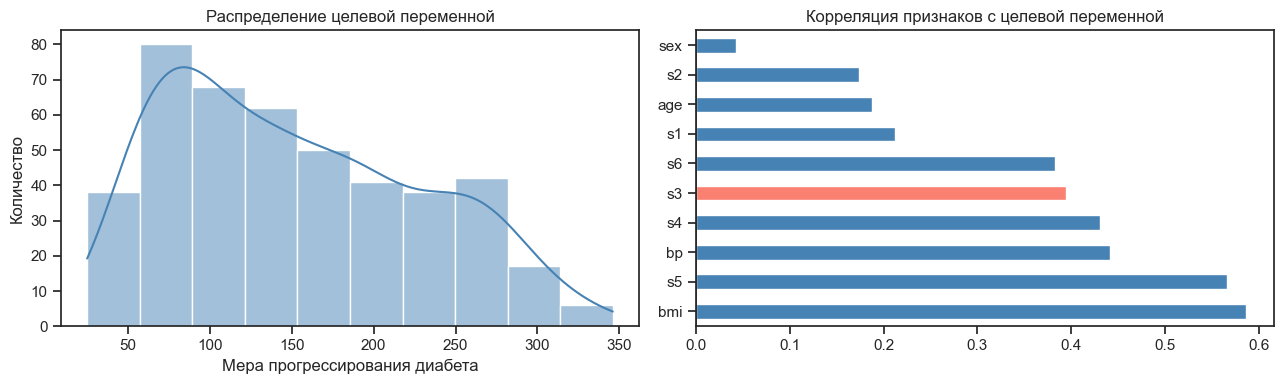

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df['target'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Распределение целевой переменной')
axes[0].set_xlabel('Мера прогрессирования диабета')
axes[0].set_ylabel('Количество')

corr = df.corr()['target'].drop('target')
corr_abs_sorted = corr.abs().sort_values(ascending=False)
corr = corr.loc[corr_abs_sorted.index]
colors = ['steelblue' if v >= 0 else 'salmon' for v in corr.values]
corr.abs().plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Корреляция признаков с целевой переменной')
axes[1].axvline(0, color='black', lw=0.5)

plt.tight_layout()
plt.show()

## 3. Разделение на обучающую и тестовую выборки

In [6]:
X = df.drop('target', axis=1).values.astype(float)
y = df['target'].values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка:  {X_test.shape}")

Обучающая выборка: (353, 10)
Тестовая выборка:  (89, 10)


In [7]:
def print_metrics(y_true, y_pred, model_name=""):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    if model_name:
        print(f"{model_name}")
    print(f"R²:   {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    return r2, rmse, mae

## 4. Стекинг (StackingRegressor)

Стекинг:
- базовые модели: RandomForest, GradientBoosting, ExtraTrees;
- мета-модель: Ridge;
- 5-кратная кросс-валидация при обучении.

In [8]:
base_estimators = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingRegressor(n_estimators=100, random_state=42)),
    ('et', ExtraTreesRegressor(n_estimators=100, random_state=42))
]

stacking_model = StackingRegressor(
    estimators=base_estimators,
    final_estimator=Ridge(),
    cv=5
)

stacking_model.fit(X_train_s, y_train)
y_pred_stacking = stacking_model.predict(X_test_s)

r2_stacking, rmse_stacking, mae_stacking = print_metrics(y_test, y_pred_stacking, "Stacking")

Stacking
R²:   0.4758
RMSE: 52.6983
MAE:  43.8293


## 5. Многослойный персептрон (MLPRegressor)

Многослойный персептрон: три скрытых слоя (128 нейронов, 64 нейрона, 32 нейрона), функция активации ReLU, оптимизатор Adam.

In [9]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_model.fit(X_train_s, y_train)
y_pred_mlp = mlp_model.predict(X_test_s)

r2_mlp, rmse_mlp, mae_mlp = print_metrics(y_test, y_pred_mlp, "MLP")

MLP
R²:   0.4364
RMSE: 54.6461
MAE:  43.2147


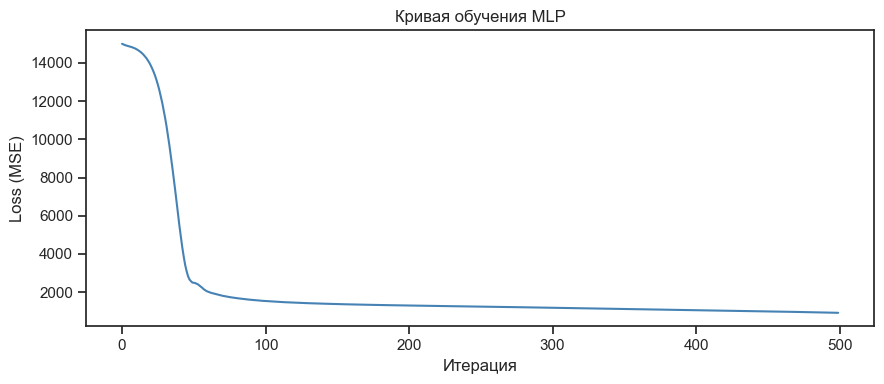

In [10]:
plt.figure(figsize=(9, 4))
plt.plot(mlp_model.loss_curve_, color='steelblue')
plt.title('Кривая обучения MLP')
plt.xlabel('Итерация')
plt.ylabel('Loss (MSE)')
plt.tight_layout()
plt.show()

## 6. МГУА — метод группового учёта аргументов (библиотека `gmdh`)

- **COMBI** — линейный метод: перебирает комбинации пар признаков, строит линейные полиномы.
- **MIA** — нелинейный метод: на каждом слое строит квадратичные полиномы от пар признаков, выходы предыдущего слоя становятся входами следующего.

In [11]:
combi_model = gmdh.Combi()
combi_model.fit(
    X_train_s, y_train,
    verbose=1, n_jobs=-1,
    criterion=gmdh.Criterion(gmdh.CriterionType.REGULARITY)
)
print()
print("Лучший полином COMBI:")
print(combi_model.get_best_polynomial())
print()
y_pred_combi = combi_model.predict(X_test_s)
r2_combi, rmse_combi, mae_combi = print_metrics(y_test, y_pred_combi, "COMBI")

LEVEL 1  [>                        ] 0% :00s] (10 combinations)
Лучший полином COMBI:
y = 25.4693*x3 + 13.7202*x4 - 14.2228*x7 + 21.1745*x9 + 156.063

COMBI
R²:   0.4480
RMSE: 54.0772
MAE:  44.0490
LEVEL 1  [=========================] 100% :00s] (10 combinations) error=685817.359607
LEVEL 2  [=========================] 100% :00s] (45 combinations) error=582631.111858
LEVEL 3  [=========================] 100% :00s] (120 combinations) error=548059.758581
LEVEL 4  [=========================] 100% :00s] (210 combinations) error=538305.43562
LEVEL 5  [=========================] 100% :00s] (252 combinations) error=538430.662711


In [12]:
mia_model = gmdh.Mia()
mia_model.fit(
    X_train_s, y_train,
    verbose=1, n_jobs=-1,
    k_best=5,
    criterion=gmdh.Criterion(gmdh.CriterionType.REGULARITY),
    polynomial_type=gmdh.PolynomialType.QUADRATIC
)
print()
y_pred_mia = mia_model.predict(X_test_s)
r2_mia, rmse_mia, mae_mia = print_metrics(y_test, y_pred_mia, "MIA")


LEVEL 1  [>                        ] 0% :00s] (45 combinations)MIA
R²:   0.2709
RMSE: 62.1532
MAE:  47.1505
LEVEL 1  [=========================] 100% :00s] (45 combinations) error=579145.144851
LEVEL 2  [=========================] 100% :00s] (10 combinations) error=556425.248724
LEVEL 3  [=========================] 100% :00s] (10 combinations) error=545780.488304
LEVEL 4  [=========================] 100% :00s] (10 combinations) error=540823.988413
LEVEL 5  [=========================] 100% :00s] (10 combinations) error=531859.825136
LEVEL 6  [=========================] 100% :00s] (10 combinations) error=550384.854992


## 7. Сравнение моделей

In [13]:
results = pd.DataFrame({
    'Модель': ['Stacking', 'MLP', 'COMBI', 'MIA'],
    'R²':   [r2_stacking, r2_mlp, r2_combi, r2_mia],
    'RMSE': [rmse_stacking, rmse_mlp, rmse_combi, rmse_mia],
    'MAE':  [mae_stacking, mae_mlp, mae_combi, mae_mia]
})

results = results.sort_values('R²', ascending=False).reset_index(drop=True)
print("Результаты всех моделей:")
results.round(4)

Результаты всех моделей:


,Модель,R²,RMSE,MAE
0,Stacking,0.4758,52.6983,43.8293
1,COMBI,0.4480,54.0772,44.0490
2,MLP,0.4364,54.6461,43.2147
3,MIA,0.2709,62.1532,47.1505


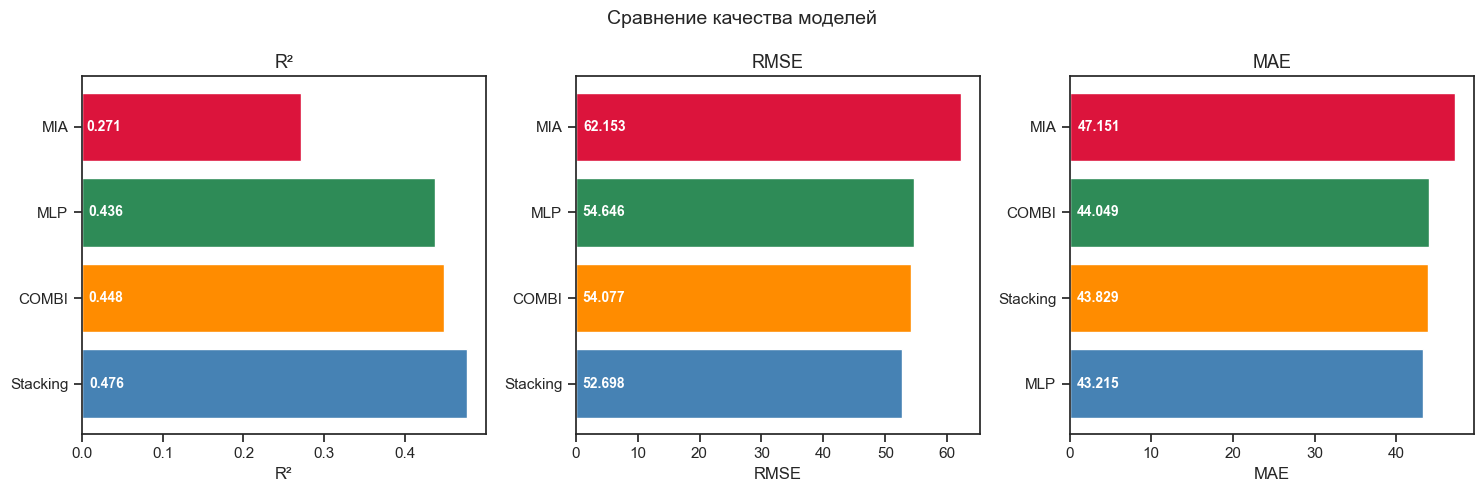

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.suptitle('Сравнение качества моделей', fontsize=14)

colors = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for ax, metric, ascending in zip(axes, ['R²', 'RMSE', 'MAE'], [False, True, True]):
    data_sorted = results.sort_values(metric, ascending=ascending)
    bars = ax.barh(data_sorted['Модель'], data_sorted[metric], color=colors)
    ax.set_title(metric, fontsize=13)
    ax.set_xlabel(metric)
    for bar, val in zip(bars, data_sorted[metric]):
        ax.text(bar.get_width() * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

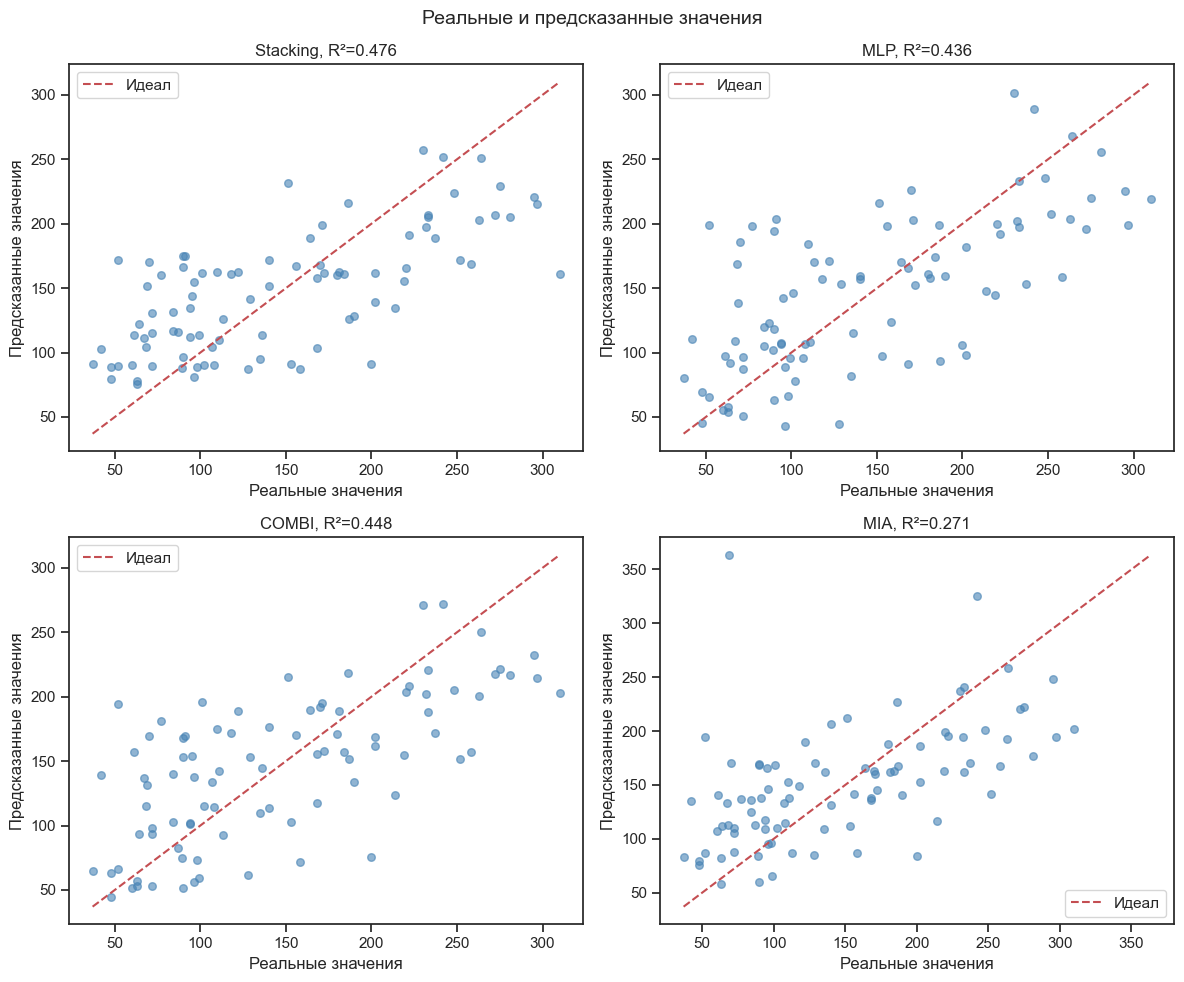

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.suptitle('Реальные и предсказанные значения', fontsize=14)

models_info = [
    ('Stacking', y_pred_stacking, r2_stacking),
    ('MLP', y_pred_mlp, r2_mlp),
    ('COMBI', y_pred_combi, r2_combi),
    ('MIA', y_pred_mia, r2_mia),
]

for ax, (name, y_pred, r2) in zip(axes.flatten(), models_info):
    ax.scatter(y_test, y_pred, alpha=0.6, color='steelblue', s=30)
    lo = min(y_test.min(), y_pred.min())
    hi = max(y_test.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5, label='Идеал')
    ax.set_xlabel('Реальные значения')
    ax.set_ylabel('Предсказанные значения')
    ax.set_title(f'{name}, R²={r2:.3f}')
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Выводы

### Сравнение моделей

| Модель | R² | RMSE | MAE |
|---|---|---|---|
| **Stacking** | 0.4758 | 52.70 | 43.83 |
| **COMBI** | 0.4480 | 54.08 | 44.05 |
| **MLP** | 0.4364 | 54.65 | 43.21 |
| **MIA** | 0.2709 | 62.15 | 47.15 |

### Наблюдения

- **StackingRegressor** показывает наилучший R² (0.476), объединяя сильные стороны трёх ансамблевых моделей через мета-модель Ridge.
- **COMBI** занимает второе место (R² = 0.448). Это объясняется тем, что в датасете Diabetes зависимости преимущественно линейны.
- **MLPRegressor** занимает третье место (R² = 0.436). Это объясняется тем, что нейронные сети труднее обучить без переобучения на небольших датасетах.
- **MIA** показывает наиболее низкий R² (0.271): квадратичные взаимодействия признаков добавляют лишнюю на данном датасете сложность, что приводит к переобучению на малой обучающей выборке.